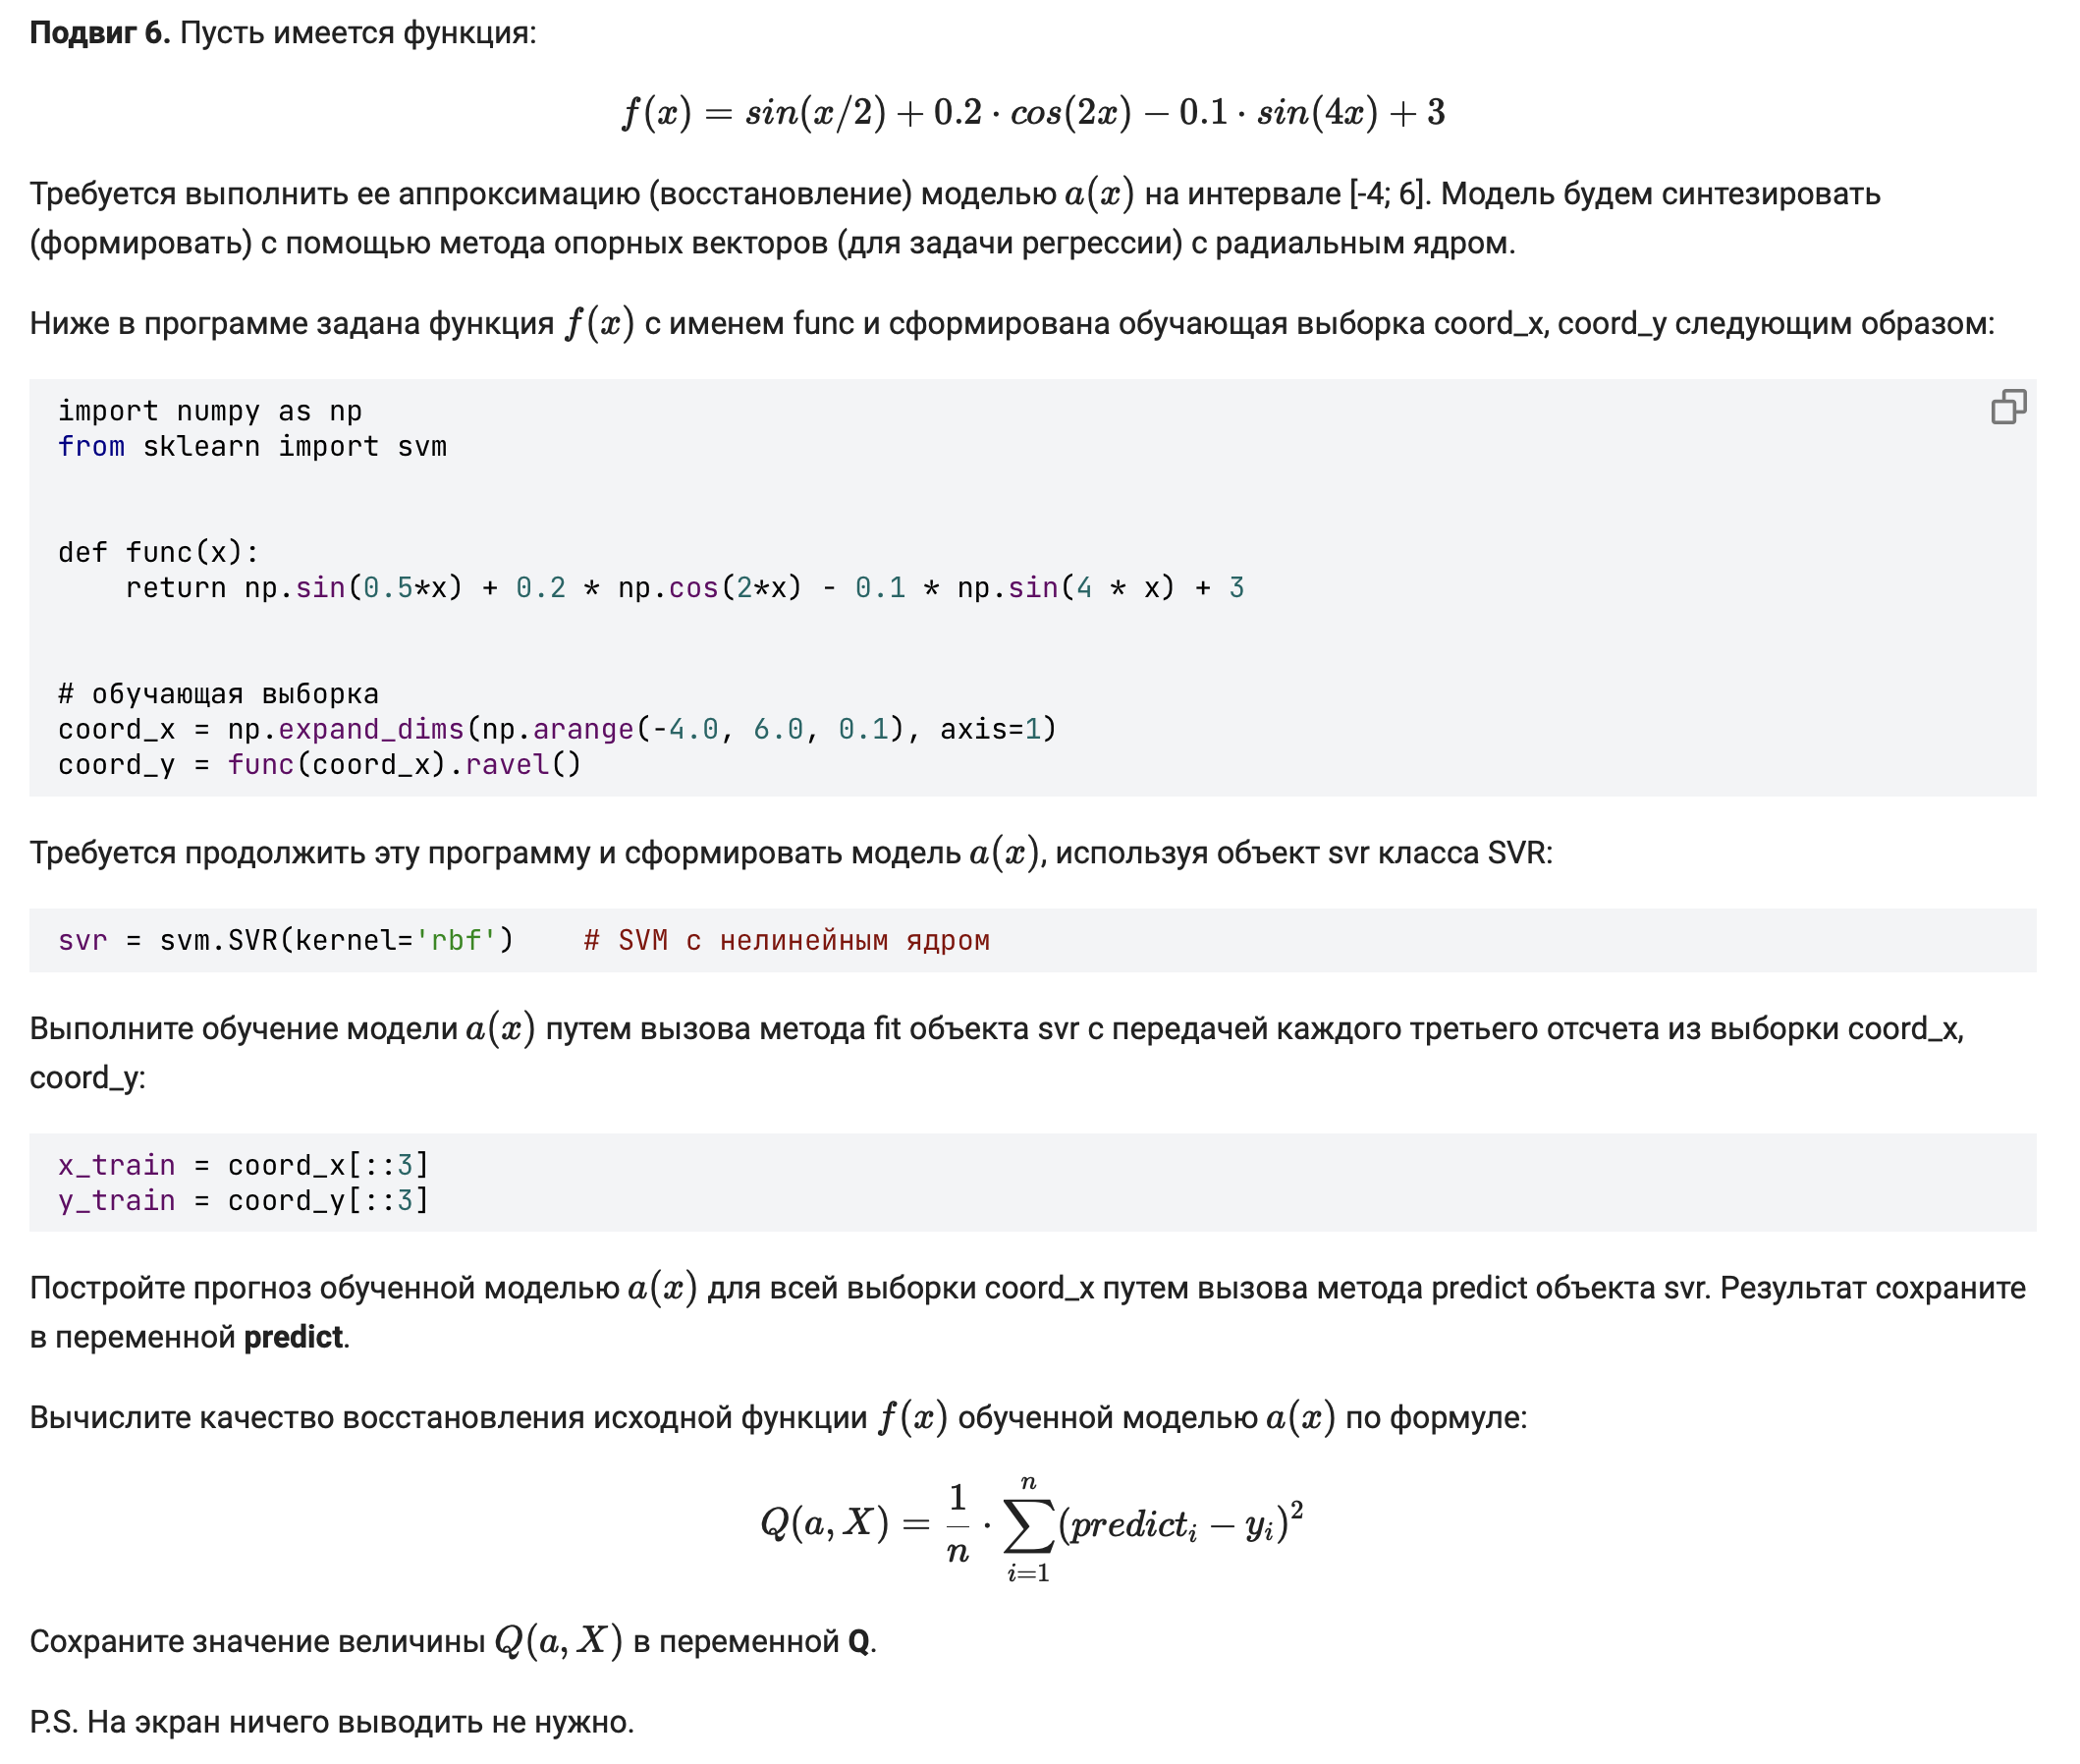

In [2]:
import numpy as np
from sklearn import svm


def func(x):
    return np.sin(0.5*x) + 0.2 * np.cos(2*x) - 0.1 * np.sin(4 * x) + 3


# обучающая выборка
coord_x = np.expand_dims(np.arange(-4.0, 6.0, 0.1), axis=1)
coord_y = func(coord_x).ravel()

# здесь продолжайте программу
model = svm.SVR(kernel='rbf')
x_train = coord_x[::3]
y_train = coord_y[::3]

model.fit(x_train, y_train)

predict = model.predict(coord_x)
Q = np.mean((predict - coord_y) ** 2)

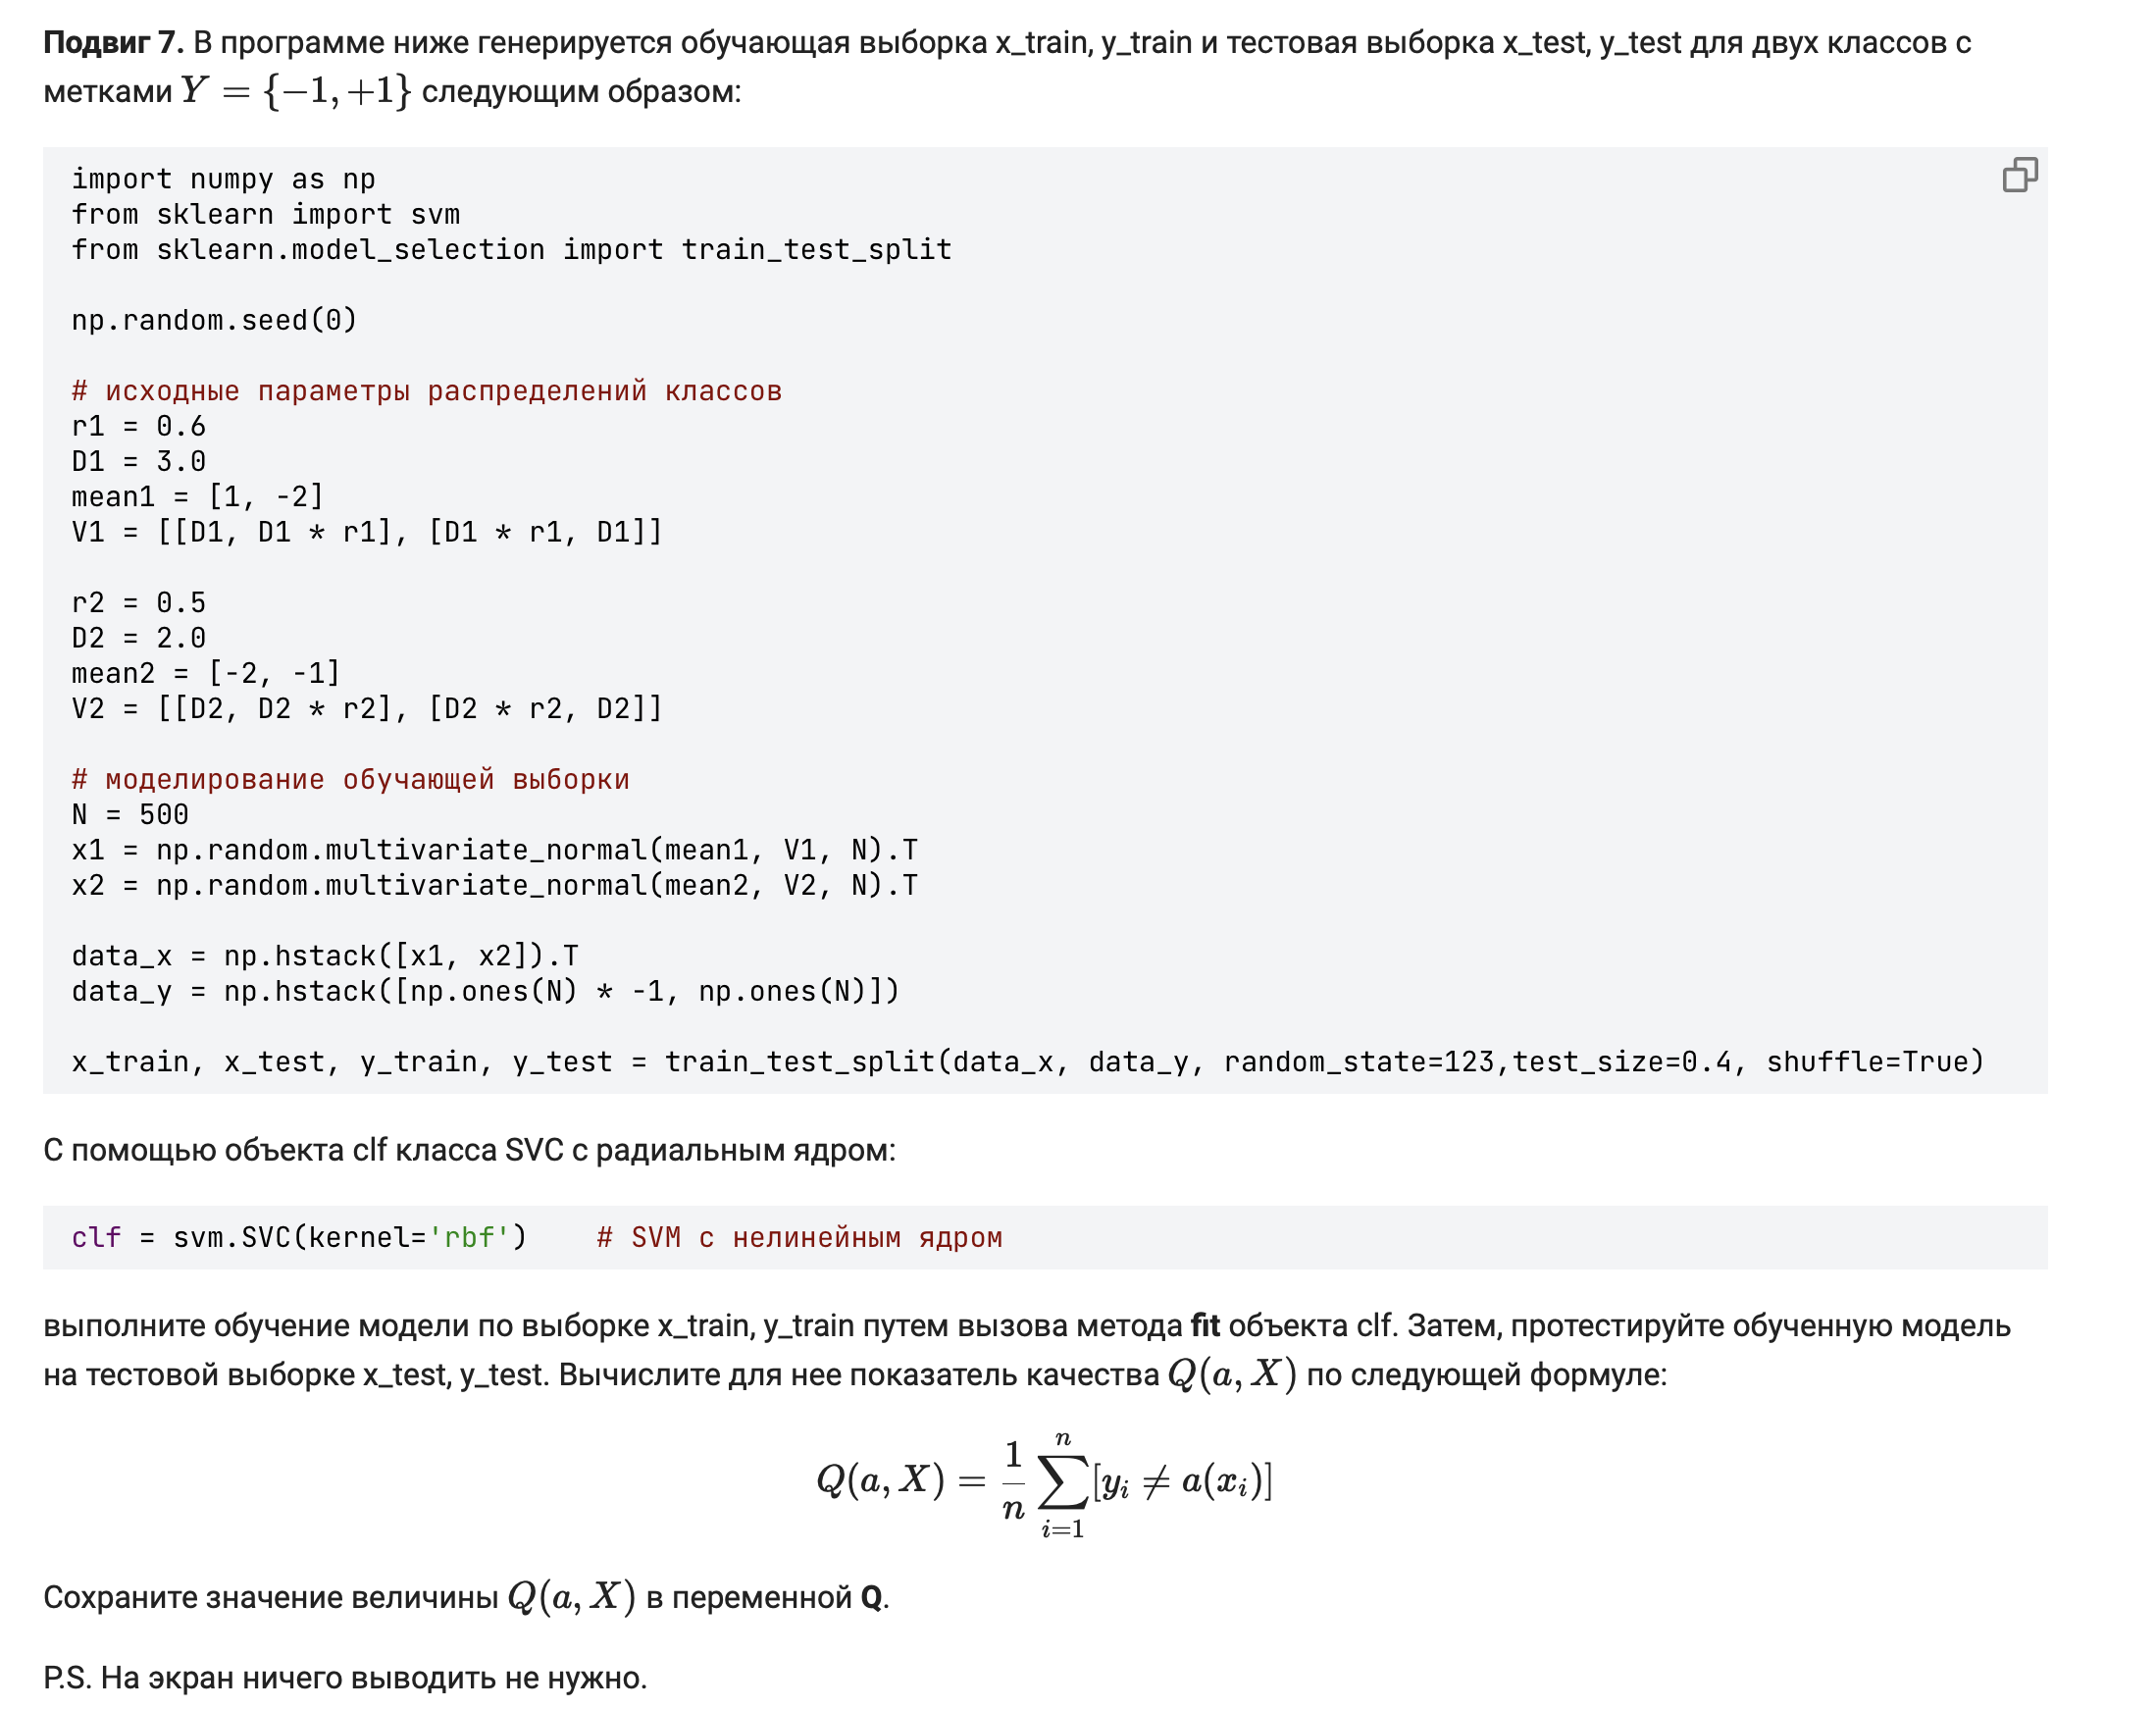

In [6]:
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split

np.random.seed(0)

# исходные параметры распределений классов
r1 = 0.6
D1 = 3.0
mean1 = [1, -2]
V1 = [[D1, D1 * r1], [D1 * r1, D1]]

r2 = 0.5
D2 = 2.0
mean2 = [-2, -1]
V2 = [[D2, D2 * r2], [D2 * r2, D2]]

# моделирование обучающей выборки
N = 500
x1 = np.random.multivariate_normal(mean1, V1, N).T
x2 = np.random.multivariate_normal(mean2, V2, N).T

data_x = np.hstack([x1, x2]).T
data_y = np.hstack([np.ones(N) * -1, np.ones(N)])

x_train, x_test, y_train, y_test = train_test_split(data_x, data_y, random_state=123,test_size=0.4, shuffle=True)

# здесь продолжайте программу
kernels = ['linear', 'poly', 'rbf']
res = []
for k in kernels:
    clf = svm.SVC(kernel=k)
    clf.fit(x_train, y_train)
    Q = np.mean(clf.predict(x_test) != y_test)
    res += [Q]
res

[np.float64(0.0875), np.float64(0.115), np.float64(0.08)]